In [23]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime

startDate = '2018-01-01'
endDate = '2026-06-24'

tickers = ['GLD', 'USO', 'ITA', 'EEM']

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [24]:
import os

# Fixed by Claude code: Set the cache directory for yfinance to avoid permission issues
cacheDirection = os.path.join(os.path.expanduser('~'), 'yfinance_cache')
os.makedirs(cacheDirection, exist_ok=True)
yf.set_tz_cache_location(cacheDirection)

rawMarket = yf.download(
    tickers = tickers, 
    start = startDate, 
    end = endDate,
    auto_adjust = True
)

print(f'Shape: {rawMarket.shape[0]:,} rows, {rawMarket.shape[1]:,} columns')
print(f'Date range: {rawMarket.index.min()} to {rawMarket.index.max()}')
rawMarket.head()

[*********************100%***********************]  4 of 4 completed

Shape: 2,129 rows, 20 columns
Date range: 2018-01-02 00:00:00 to 2026-06-23 00:00:00


Price           Close                                         High  \
Ticker            EEM         GLD        ITA        USO        EEM   
Date                                                                 
2018-01-02  39.776558  125.150002  86.677139  96.559998  39.826269   
2018-01-03  40.157669  124.820000  86.805916  98.720001  40.215664   
2018-01-04  40.356510  125.459999  87.413139  98.959999  40.414505   
2018-01-05  40.704487  125.330002  88.199722  98.480003  40.712771   
2018-01-08  40.704487  125.309998  88.733322  99.040001  40.779052   

Price                                               Low              \
Ticker             GLD        ITA        USO        EEM         GLD   
Date                                                                  
2018-01-02  125.180000  87.068139  96.800003  39.544577  124.389999   
2018-01-03  125.089996  86.930110  98.879997  40.000251  124.099998   
2018-01-04  125.849998  87.463739  99.360001  40.240520  124.739998   
2018-01-05  125.480003  88.236523  98.639999  40.406224  124.830002   
2018-01-08  125.320000  88.880524  99.040001  40.613351  124.900002   

Price                                  Open                                    \
Ticker            ITA        USO        EEM         GLD        ITA        USO   
Date                                                                            
2018-01-02  86.253943  96.080002  39.586002  124.660004  86.920944  96.559998   
2018-01-03  86.433313  97.360001  40.008538  125.050003  86.874912  97.360001   
2018-01-04  86.948545  98.480003  40.257090  124.889999  87.123339  98.639999   
2018-01-05  87.463725  97.680000  40.447649  124.930000  87.758123  98.239998   
2018-01-08  88.089330  98.160004  40.646492  125.199997  88.553924  98.480003   

Price         Volume                             
Ticker           EEM       GLD     ITA      USO  
Date                                             
2018-01-02  68969400  11762500  501000  1497588  
2018-01-03  56228700   7904300  578400  2156150  
2018-01-04  52154900   7329700  552800  1480988  
2018-01-05  50026900   5739900  557000  1609888  
2018-01-08  36998200   3566700  556600  1229225

In [25]:
rawMarket.columns = rawMarket.columns.map(lambda x: f'{x[0]}_{x[1]}')

print('Flattened column names:')
print(rawMarket.columns.tolist())

Flattened column names:
['Close_EEM', 'Close_GLD', 'Close_ITA', 'Close_USO', 'High_EEM', 'High_GLD', 'High_ITA', 'High_USO', 'Low_EEM', 'Low_GLD', 'Low_ITA', 'Low_USO', 'Open_EEM', 'Open_GLD', 'Open_ITA', 'Open_USO', 'Volume_EEM', 'Volume_GLD', 'Volume_ITA', 'Volume_USO']


Nulls:
Close_EEM     0
Close_GLD     0
Close_ITA     0
Close_USO     0
High_EEM      0
High_GLD      0
High_ITA      0
High_USO      0
Low_EEM       0
Low_GLD       0
Low_ITA       0
Low_USO       0
Open_EEM      0
Open_GLD      0
Open_ITA      0
Open_USO      0
Volume_EEM    0
Volume_GLD    0
Volume_ITA    0
Volume_USO    0
dtype: int64


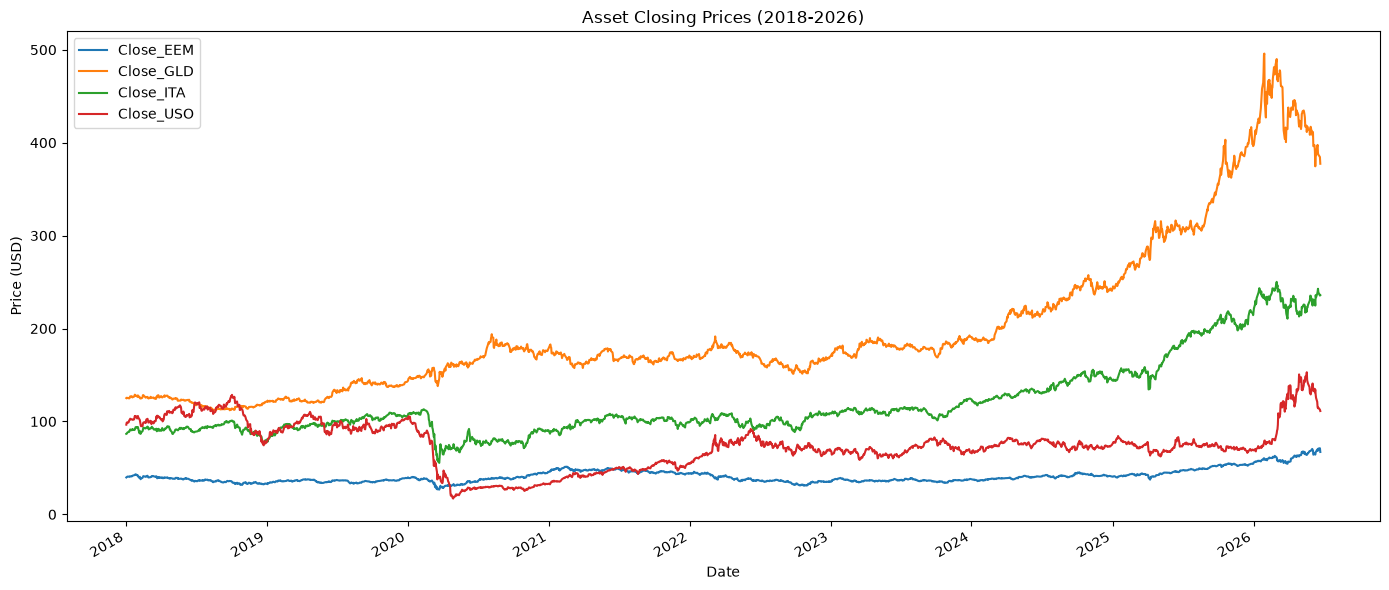

In [26]:
print('Nulls:')
print(rawMarket.isnull().sum())

closeColumns = ['Close_EEM', 'Close_GLD', 'Close_ITA', 'Close_USO']

fig, ax = plt.subplots(figsize=(14, 6))
rawMarket[closeColumns].plot(ax=ax)

ax.set_title('Asset Closing Prices (2018-2026)')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
plt.tight_layout()
plt.show()

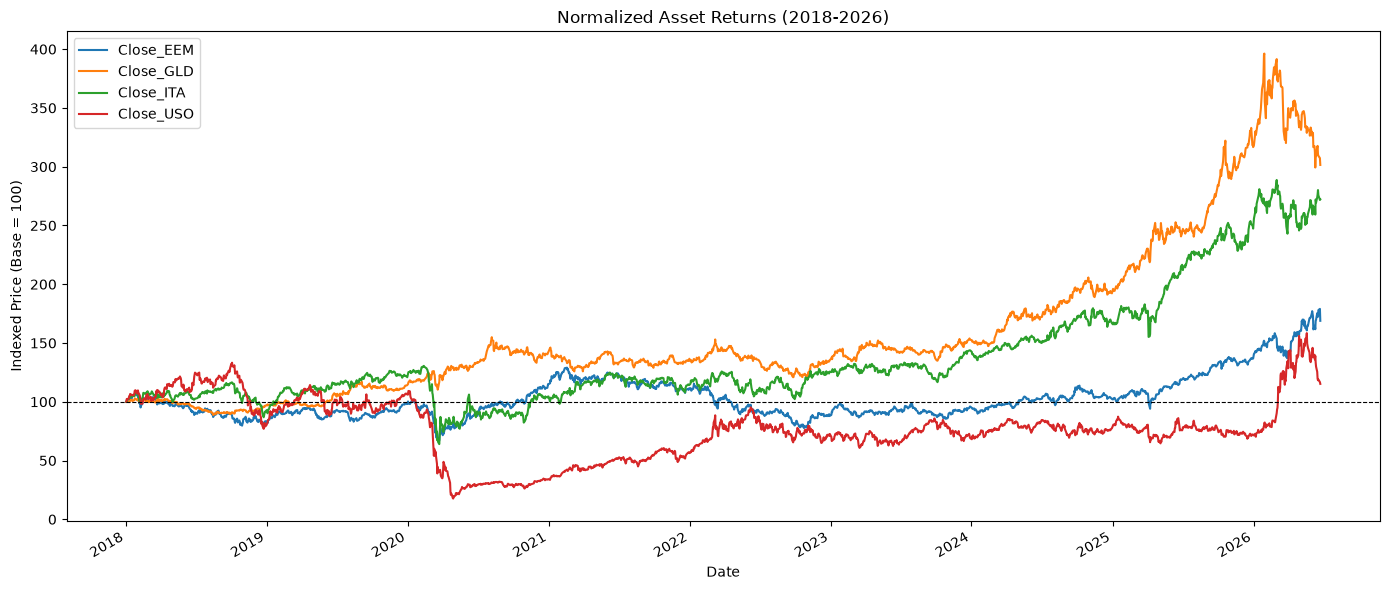

In [27]:
# Normalize closing prices for comparison
closeCols2 = rawMarket[closeColumns].copy()
normalized = (closeCols2 / closeCols2.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(14, 6))
normalized.plot(ax=ax)

ax.axhline(y=100, color='black', linestyle='--', linewidth=0.8)
ax.set_title('Normalized Asset Returns (2018-2026)')
ax.set_xlabel('Date')
ax.set_ylabel('Indexed Price (Base = 100)')
plt.tight_layout()
plt.show()

In [29]:
rawVIX = yf.download(
    tickers = '^VIX', 
    start = startDate, 
    end = endDate, 
    auto_adjust = True
)

vixClose = rawVIX['Close'].copy()
vixClose.columns = ['Close_VIX']

print(f'Shape: {vixClose.shape}')
print(f'Nulls: {vixClose.isnull().sum().sum()}')

[*********************100%***********************]  1 of 1 completed

Shape: (2130, 1)
Nulls: 0


In [30]:
marketDF = pd.concat([rawMarket, vixClose], axis=1, join='inner')

print(f'Shape: {marketDF.shape[0]:,} rows, {marketDF.shape[1]:,} columns')
print(f'Nulls: {marketDF.isnull().sum().sum()}')
marketDF.head()

Shape: 2,129 rows, 21 columns
Nulls: 0


,Close_EEM,Close_GLD,Close_ITA,Close_USO,High_EEM,High_GLD,High_ITA,High_USO,Low_EEM,Low_GLD,...,Low_USO,Open_EEM,Open_GLD,Open_ITA,Open_USO,Volume_EEM,Volume_GLD,Volume_ITA,Volume_USO,Close_VIX
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,39.776558,125.150002,86.677139,96.559998,39.826269,125.180000,87.068139,96.800003,39.544577,124.389999,...,96.080002,39.586002,124.660004,86.920944,96.559998,68969400,11762500,501000,1497588,9.77
2018-01-03,40.157669,124.820000,86.805916,98.720001,40.215664,125.089996,86.930110,98.879997,40.000251,124.099998,...,97.360001,40.008538,125.050003,86.874912,97.360001,56228700,7904300,578400,2156150,9.15
2018-01-04,40.356510,125.459999,87.413139,98.959999,40.414505,125.849998,87.463739,99.360001,40.240520,124.739998,...,98.480003,40.257090,124.889999,87.123339,98.639999,52154900,7329700,552800,1480988,9.22
2018-01-05,40.704487,125.330002,88.199722,98.480003,40.712771,125.480003,88.236523,98.639999,40.406224,124.830002,...,97.680000,40.447649,124.930000,87.758123,98.239998,50026900,5739900,557000,1609888,9.22
2018-01-08,40.704487,125.309998,88.733322,99.040001,40.779052,125.320000,88.880524,99.040001,40.613351,124.900002,...,98.160004,40.646492,125.199997,88.553924,98.480003,36998200,3566700,556600,1229225,9.52


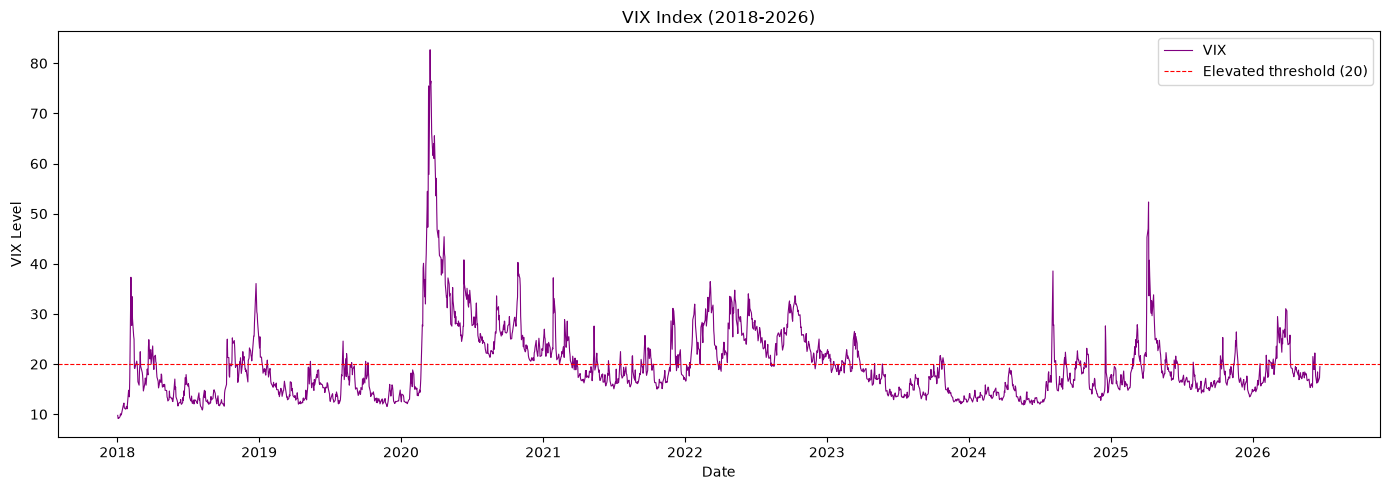

In [31]:
# Plot VIX over time 
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(marketDF.index, marketDF['Close_VIX'], color='purple', label='VIX', linewidth=0.8)

ax.axhline(y=20, color='red', linestyle='--', linewidth=0.8, label='Elevated threshold (20)')
ax.set_title('VIX Index (2018-2026)')
ax.set_xlabel('Date')   
ax.set_ylabel('VIX Level')  
ax.legend()
plt.tight_layout()
plt.show()

In [32]:
rawPath = '../data/raw/rawMarket.csv'
marketDF.to_csv(rawPath, index=True)
print('rawPath:', rawPath)

closeColumns = ['Close_EEM', 'Close_GLD', 'Close_ITA', 'Close_USO', 'Close_VIX']
processedPath = '../data/processed/marketDF.csv'
marketDF[closeColumns].to_csv(processedPath, index=True)
print('processedPath:', processedPath)

rawPath: ../data/raw/rawMarket.csv
processedPath: ../data/processed/marketDF.csv
